# HRRR 2m Temperature Versus Surface Observations

Download HRRR forecast-hour-zero 2m temperature for one UTC datetime, download matching ASOS observations from the IEM observation request URL, and map the forecast with observation-minus-HRRR errors.


In [1]:
from datetime import datetime, timedelta, timezone
from io import StringIO
from pathlib import Path
import os

repo_tmp = Path("tmp").resolve()
data_dir = Path("data").resolve()
(repo_tmp / "matplotlib").mkdir(parents=True, exist_ok=True)
(repo_tmp / "herbie-config").mkdir(parents=True, exist_ok=True)
(repo_tmp / "cache").mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(repo_tmp / "matplotlib"))
os.environ.setdefault("HERBIE_CONFIG_PATH", str(repo_tmp / "herbie-config"))
os.environ.setdefault("XDG_CACHE_HOME", str(repo_tmp / "cache"))

import numpy as np
import pandas as pd
import requests
import xarray as xr
from herbie import Herbie
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
# Choose the HRRR analysis / observation valid time here.
# HRRR fxx=0 is valid at exactly this model run time.
valid_time_utc = datetime(2026, 6, 2, 18, 0, tzinfo=timezone.utc)

# ASOS reports often arrive a few minutes before the top of the hour.
# The notebook downloads this window and keeps the nearest report per station.
obs_window_minutes = 30

# IEM ASOS observation request service.
observations_url = "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"

# CONUS plotting bounds: west, east, south, north.
map_extent = [-125.0, -66.5, 24.0, 50.0]

# Station error colors saturate at this many degrees F.
error_color_limit_f = 15.0

# Plot every Nth HRRR grid point so Cartopy renders quickly.
hrrr_plot_stride = 5


In [3]:
def to_lon180(lon):
    """Convert longitude values from 0..360 to -180..180 when needed."""
    return ((np.asarray(lon) + 180.0) % 360.0) - 180.0


def download_hrrr_2m_temperature(valid_time):
    """Download HRRR forecast-hour-zero 2m temperature and return a compact dataset."""
    run_time = pd.Timestamp(valid_time).tz_convert("UTC").tz_localize(None).to_pydatetime()

    hrrr = Herbie(run_time, model="hrrr", product="sfc", fxx=0, save_dir=data_dir)
    subset_path = hrrr.download(":TMP:2 m above ground:", verbose=False)
    if isinstance(subset_path, (list, tuple)):
        subset_path = subset_path[0]

    ds = xr.open_dataset(
        subset_path,
        engine="cfgrib",
        backend_kwargs={"indexpath": ""},
    )

    if "t2m" not in ds:
        raise KeyError(f"Expected HRRR variable 't2m', found {list(ds.data_vars)}")

    temp_k = ds["t2m"].squeeze()
    temp_f = ((temp_k - 273.15) * 9.0 / 5.0 + 32.0).load()
    latitude = ds["latitude"].load()
    longitude = (((ds["longitude"] + 180.0) % 360.0) - 180.0).load()
    ds.close()

    return xr.Dataset(
        data_vars={"t2m_f": temp_f},
        coords={
            "latitude": latitude,
            "longitude": longitude,
        },
        attrs={
            "model": "HRRR",
            "product": "sfc",
            "forecast_hour": 0,
            "valid_time_utc": pd.Timestamp(valid_time).isoformat(),
            "grib_subset_path": str(subset_path),
        },
    )


hrrr_ds = download_hrrr_2m_temperature(valid_time_utc)
hrrr_ds


✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-02 18:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


<xarray.Dataset> Size: 38MB
Dimensions:            (y: 1059, x: 1799)
Coordinates:
    latitude           (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
    longitude          (y, x) float64 15MB -122.7 -122.7 ... -60.95 -60.92
    time               datetime64[ns] 8B 2026-06-02T18:00:00
    step               timedelta64[ns] 8B 00:00:00
    heightAboveGround  float64 8B 2.0
    valid_time         datetime64[ns] 8B 2026-06-02T18:00:00
Dimensions without coordinates: y, x
Data variables:
    t2m_f              (y, x) float32 8MB 71.88 71.88 71.88 ... 39.25 39.37
Attributes:
    model:             HRRR
    product:           sfc
    forecast_hour:     0
    valid_time_utc:    2026-06-02T18:00:00+00:00
    grib_subset_path:  /home/dmmsp/Projects/observations-vs-forecasts/data/hr...

In [4]:
def download_asos_observations(valid_time, url=observations_url, window_minutes=30):
    """Download ASOS temperatures near valid_time from the IEM request/asos.py URL."""
    start = pd.Timestamp(valid_time - timedelta(minutes=window_minutes)).tz_convert("UTC")
    end = pd.Timestamp(valid_time + timedelta(minutes=window_minutes)).tz_convert("UTC")

    params = {
        "data": "tmpf",
        "year1": start.year,
        "month1": start.month,
        "day1": start.day,
        "hour1": start.hour,
        "minute1": start.minute,
        "year2": end.year,
        "month2": end.month,
        "day2": end.day,
        "hour2": end.hour,
        "minute2": end.minute,
        "tz": "UTC",
        "format": "onlycomma",
        "latlon": "yes",
        "missing": "M",
        "trace": "T",
        "direct": "yes",
    }

    response = requests.get(url, params=params, timeout=120)
    if response.status_code == 404:
        raise FileNotFoundError(f"Observation URL does not exist: {url}")
    response.raise_for_status()

    obs = pd.read_csv(StringIO(response.text), na_values=["M", "", "NaN"])
    expected = {"station", "valid", "tmpf", "lat", "lon"}
    missing = expected.difference(obs.columns)
    if missing:
        raise ValueError(f"Observation response is missing columns: {sorted(missing)}")

    obs = obs.dropna(subset=["station", "valid", "tmpf", "lat", "lon"]).copy()
    obs["valid"] = pd.to_datetime(obs["valid"], utc=True)
    obs["minutes_from_target"] = (
        obs["valid"] - pd.Timestamp(valid_time).tz_convert("UTC")
    ).abs().dt.total_seconds() / 60.0

    obs = (
        obs.sort_values(["station", "minutes_from_target"])
        .groupby("station", as_index=False)
        .first()
    )
    obs = obs[obs["minutes_from_target"] <= window_minutes].copy()
    obs["lon"] = to_lon180(obs["lon"])

    west, east, south, north = map_extent
    obs = obs[
        obs["lon"].between(west, east) & obs["lat"].between(south, north)
    ].copy()

    if obs.empty:
        raise ValueError("No valid ASOS observations were found for this datetime/window.")

    return obs


obs = download_asos_observations(valid_time_utc, window_minutes=obs_window_minutes)
obs.head()


,station,valid,lon,lat,tmpf,minutes_from_target
0,00U,2026-06-02 17:55:00+00:00,-107.6604,45.7444,62.6,5.0
1,01M,2026-06-02 17:55:00+00:00,-88.2011,34.4917,81.5,5.0
2,04V,2026-06-02 17:55:00+00:00,-106.1700,38.1000,69.8,5.0
3,04W,2026-06-02 17:55:00+00:00,-92.8952,46.0229,80.6,5.0
4,05U,2026-06-02 17:55:00+00:00,-116.0051,39.6042,71.6,5.0


In [5]:
def attach_nearest_hrrr_temperature(obs_df, hrrr):
    """Attach nearest HRRR gridpoint temperature to each observation row."""
    lat = np.asarray(hrrr["latitude"])
    lon = to_lon180(hrrr["longitude"])
    temp = np.asarray(hrrr["t2m_f"])

    valid_grid = np.isfinite(lat) & np.isfinite(lon) & np.isfinite(temp)
    grid_points = np.column_stack([lat[valid_grid], lon[valid_grid]])
    grid_temp = temp[valid_grid]

    tree = cKDTree(grid_points)
    station_points = obs_df[["lat", "lon"]].to_numpy()
    distances_deg, nearest_index = tree.query(station_points, k=1)

    matched = obs_df.copy()
    matched["hrrr_tmpf"] = grid_temp[nearest_index]
    matched["obs_minus_hrrr_f"] = matched["tmpf"] - matched["hrrr_tmpf"]
    matched["nearest_grid_distance_deg"] = distances_deg
    return matched


matched = attach_nearest_hrrr_temperature(obs, hrrr_ds)
summary = matched["obs_minus_hrrr_f"].agg(["count", "mean", "median", "std", "min", "max"])
rmse = np.sqrt(np.mean(np.square(matched["obs_minus_hrrr_f"])))
print(summary)
print(f"RMSE: {rmse:.2f} deg F")
matched.head()


count     2537.000000
mean        -0.142040
median      -0.190018
std          2.122055
min        -17.102516
max         17.109985
Name: obs_minus_hrrr_f, dtype: float64
RMSE: 2.13 deg F


,station,valid,lon,lat,tmpf,minutes_from_target,hrrr_tmpf,obs_minus_hrrr_f,nearest_grid_distance_deg
0,00U,2026-06-02 17:55:00+00:00,-107.6604,45.7444,62.6,5.0,65.690018,-3.090018,0.011483
1,01M,2026-06-02 17:55:00+00:00,-88.2011,34.4917,81.5,5.0,82.677513,-1.177513,0.015829
2,04V,2026-06-02 17:55:00+00:00,-106.1700,38.1000,69.8,5.0,71.090012,-1.290012,0.013181
3,04W,2026-06-02 17:55:00+00:00,-92.8952,46.0229,80.6,5.0,79.077515,1.522485,0.013028
4,05U,2026-06-02 17:55:00+00:00,-116.0051,39.6042,71.6,5.0,73.002518,-1.402518,0.005364


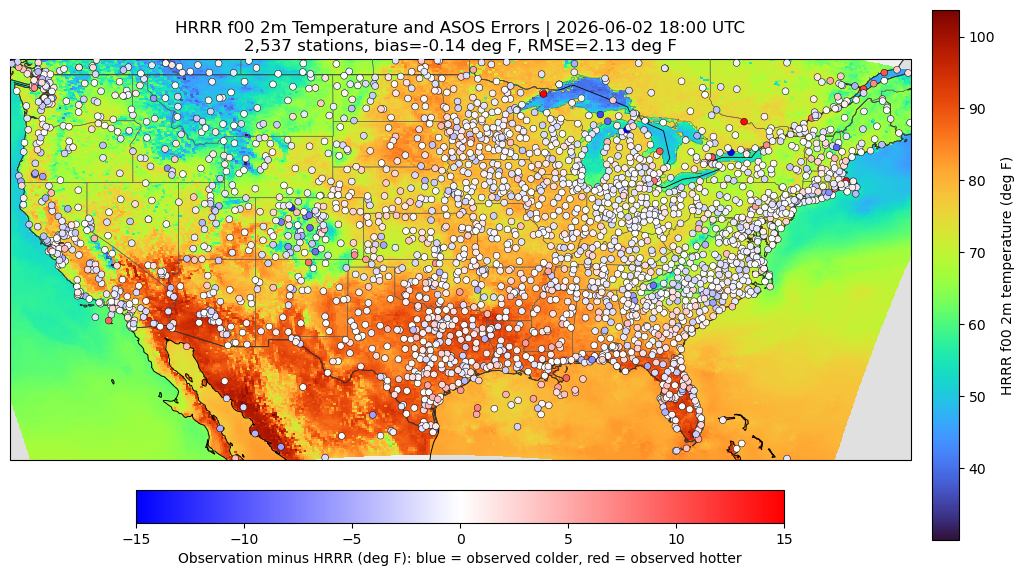

In [6]:
hrrr_plot = hrrr_ds.isel(
    y=slice(None, None, hrrr_plot_stride),
    x=slice(None, None, hrrr_plot_stride),
)

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(map_extent, crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="0.94", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="0.88", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=3)
ax.add_feature(cfeature.STATES, linewidth=0.35, edgecolor="0.35", zorder=3)

mesh = ax.pcolormesh(
    hrrr_plot["longitude"],
    hrrr_plot["latitude"],
    hrrr_plot["t2m_f"],
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="turbo",
    zorder=1,
)
temp_cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.86)
temp_cbar.set_label("HRRR f00 2m temperature (deg F)")

error_norm = TwoSlopeNorm(
    vmin=-error_color_limit_f,
    vcenter=0.0,
    vmax=error_color_limit_f,
)
scatter = ax.scatter(
    matched["lon"],
    matched["lat"],
    c=matched["obs_minus_hrrr_f"],
    cmap="bwr",
    norm=error_norm,
    s=24,
    edgecolor="black",
    linewidth=0.35,
    transform=ccrs.PlateCarree(),
    zorder=4,
)
err_cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.05, shrink=0.72)
err_cbar.set_label("Observation minus HRRR (deg F): blue = observed colder, red = observed hotter")

valid_label = pd.Timestamp(valid_time_utc).strftime("%Y-%m-%d %H:%M UTC")
ax.set_title(
    f"HRRR f00 2m Temperature and ASOS Errors | {valid_label}\n"
    f"{len(matched):,} stations, bias={matched['obs_minus_hrrr_f'].mean():.2f} deg F, "
    f"RMSE={rmse:.2f} deg F"
)
plt.show()
